---

# University of Liverpool

## COMP634 - Applied AI

---

This notebook is associated with Assignment 1. Use it to complete the assignment by following the instructions provided in each section, which includes a text cell describing the requirements. For additional details, see the Canvas.

Use this first cell to import the necessary libraries.

In [8]:
# import libraries here
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.figsize": (7,4), "axes.grid": True})
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Load data
CSV_PATH = "/content/assignment1-dataset.csv"
TARGET_CANDIDATES = ["ObesityLvl", "NObeyesdad", "target", "class", "label"]

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5




# 1. **Data Management**


In this part, you need to:

1.   analyse and prepare the data. Use plots, graphs, and tables (such as histogram, box plots, scatterplots etc.) to better analyse the dataset and identify issues or potential improvements in the data, including (but not limited to) unnecessary feature/variable which can be dropped/removed, standardization, encoding, etc;
2.   split the data and define your experimental protocol (such as cross-validation or k-fold).

In [34]:
# Write your proposed solution code here. Create more code cells if you find it necessary


df = pd.read_csv(CSV_PATH)
print("Initial shape:", df.shape)
display(df.head(3))

#Removing Outliers
df = df[
    (df['Age'] <= 100) &
    (df['Height'] <= 2.2) &
    (df['Weight'] <= 200)
].copy()

print(f" Outlier removal complete. Remaining rows: {len(df)}")

# Dtypes, missing, uniques
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nUnique values per column:")
print(df.nunique())




Initial shape: (2111, 18)


,Gender,Age,Height,Weight,family_overweight,HCF,VegMeals,Meals,FD,MealsBetw,SMOKE,WaterQ,CaloriesMonitor,PhysAct,TechUsage,AlcConsume,TransMeans,ObesityLvl
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,0.832932,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.056377,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,0.962160,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight


 Outlier removal complete. Remaining rows: 2108

Data types:
Gender                object
Age                  float64
Height               float64
Weight               float64
family_overweight     object
HCF                   object
VegMeals             float64
Meals                float64
FD                   float64
MealsBetw             object
SMOKE                 object
WaterQ               float64
CaloriesMonitor       object
PhysAct              float64
TechUsage            float64
AlcConsume            object
TransMeans            object
ObesityLvl            object
dtype: object

Missing values per column:
Gender               0
Age                  0
Height               0
Weight               0
family_overweight    0
HCF                  0
VegMeals             0
Meals                0
FD                   0
MealsBetw            0
SMOKE                0
WaterQ               0
CaloriesMonitor      0
PhysAct              0
TechUsage            0
AlcConsume           0
TransMe

In [35]:
# Detect target column from candidates

target = None
for cand in TARGET_CANDIDATES:
    if cand in df.columns:
        target = cand
        break

if target is None:
    # Heuristic fallback: pick a categorical column with relatively few unique values
    cat_like = [c for c in df.columns if df[c].dtype == 'object' or str(df[c].dtype).startswith('category')]
    if cat_like:
        # choose the one with the least unique values > 1
        candidates = [(c, df[c].nunique()) for c in cat_like if df[c].nunique() > 1]
        target = min(candidates, key=lambda t: t[1])[0] if candidates else cat_like[0]
    else:
        raise ValueError("Could not find a suitable target column. Please set TARGET_CANDIDATES or create a 'target' column.")

print("Target column:", target)


Target column: ObesityLvl


In [36]:

# Count duplicates (full-row duplicates)
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates dropped. New shape:", df.shape)
else:
    print("No duplicate rows to drop.")

# Drop clear ID-like columns if present
id_like = [c for c in df.columns if c.lower() in ["id", "index", "rowid"]]
if id_like:
    print("Dropping potential ID columns:", id_like)
    df = df.drop(columns=id_like)

# Convert target to category if object
if df[target].dtype == "object":
    df[target] = df[target].astype("category")

display(df.head(3))

Duplicate rows found: 20
Duplicates dropped. New shape: (2088, 18)


,Gender,Age,Height,Weight,family_overweight,HCF,VegMeals,Meals,FD,MealsBetw,SMOKE,WaterQ,CaloriesMonitor,PhysAct,TechUsage,AlcConsume,TransMeans,ObesityLvl
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,0.832932,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.056377,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,0.962160,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight


Exploratory Data Analysis (EDA)

In [37]:
display(df.describe(include='all').transpose())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2088,2,Male,1053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2088.0,NaN,NaN,NaN,24.342208,6.358369,14.0,19.907404,22.841336,26.0,61.0
Height,2088.0,NaN,NaN,NaN,1.702638,0.093166,1.45,1.63,1.701575,1.769488,1.98
Weight,2088.0,NaN,NaN,NaN,86.813024,26.20038,39.0,65.498043,83.015501,108.003151,173.0
family_overweight,2088,2,yes,1723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HCF,2088,2,yes,1845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VegMeals,2088.0,NaN,NaN,NaN,2.421529,0.534362,1.0,2.0,2.395051,3.0,3.0
Meals,2088.0,NaN,NaN,NaN,2.702747,0.763587,1.0,2.701647,3.0,3.0,4.0
FD,2088.0,NaN,NaN,NaN,0.84364,0.507114,0.0,0.677387,0.950009,1.099533,2.19516
MealsBetw,2088,4,Sometimes,1760,NaN,NaN,NaN,NaN,NaN,NaN,NaN


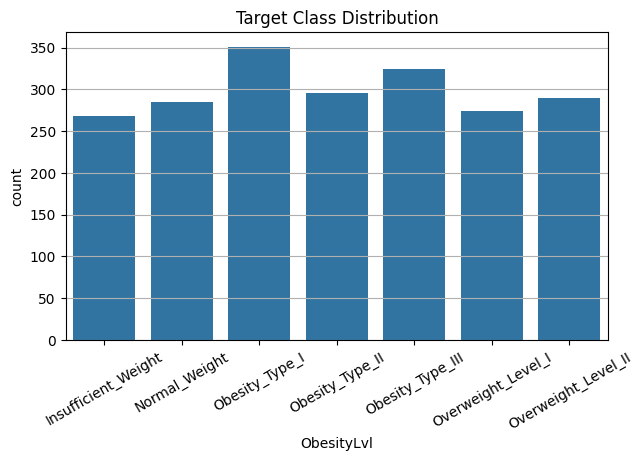

In [38]:
# Target distribution
plt.figure()
sns.countplot(x=target, data=df)
plt.title("Target Class Distribution")
plt.xticks(rotation=30)
plt.show()


In [39]:
# Identify numeric and categorical features

feature_cols = [c for c in df.columns if c != target]
num_cols = df[feature_cols].select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'Height', 'Weight', 'VegMeals', 'Meals', 'FD', 'WaterQ', 'PhysAct', 'TechUsage']
Categorical columns: ['Gender', 'family_overweight', 'HCF', 'MealsBetw', 'SMOKE', 'CaloriesMonitor', 'AlcConsume', 'TransMeans']


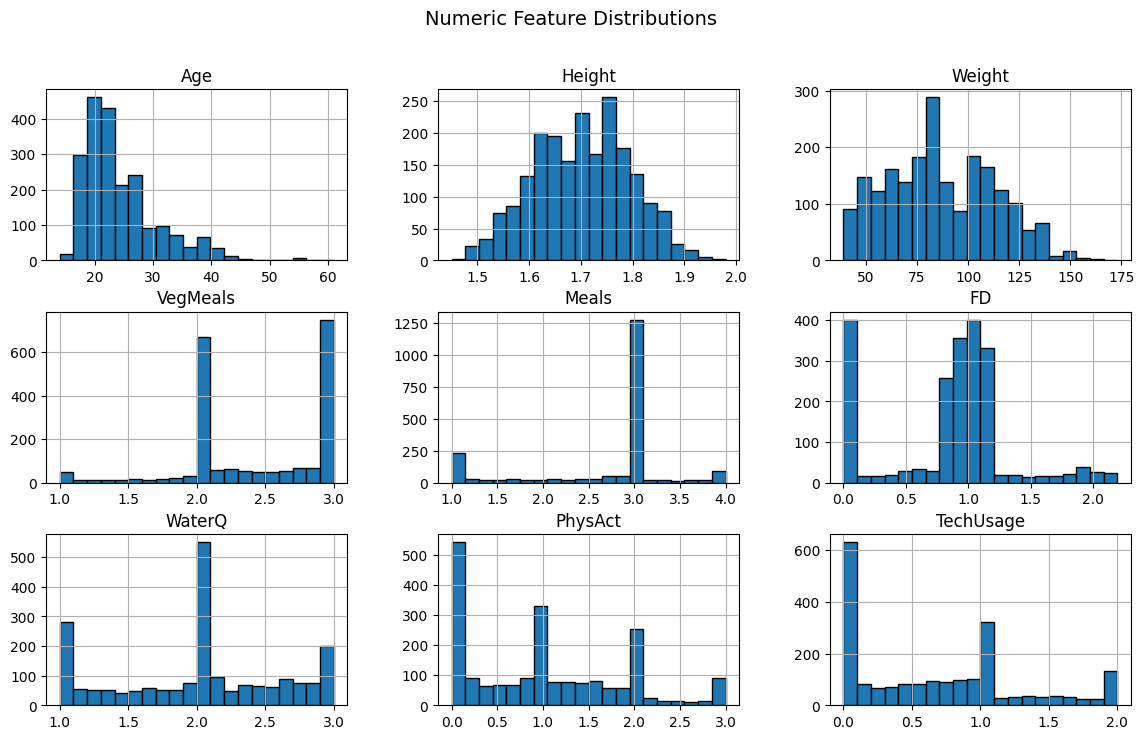

In [40]:
# Numeric distributions

if num_cols:
    df[num_cols].hist(bins=20, edgecolor="black", figsize=(14, 8))
    plt.suptitle("Numeric Feature Distributions", fontsize=14)
    plt.show()
else:
    print("No numeric columns to plot.")

<Figure size 1400x600 with 0 Axes>

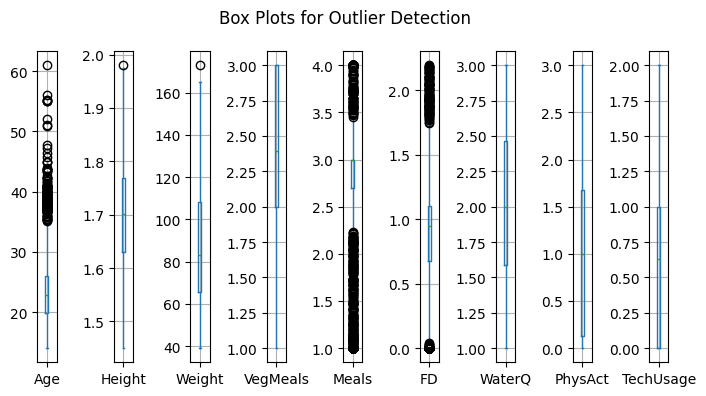

In [41]:
# Box plots for outliers

if num_cols:
    plt.figure(figsize=(14, 6))
    df[num_cols].plot(kind="box", subplots=True, layout=(1, len(num_cols)),
                      sharex=False, sharey=False)
    plt.suptitle("Box Plots for Outlier Detection")
    plt.tight_layout()
    plt.show()



Skewness of numeric features:
 Age          1.518171
TechUsage    0.607732
PhysAct      0.494528
Weight       0.244371
Height      -0.023898
WaterQ      -0.107625
FD          -0.176747
VegMeals    -0.445333
Meals       -1.143452
dtype: float64


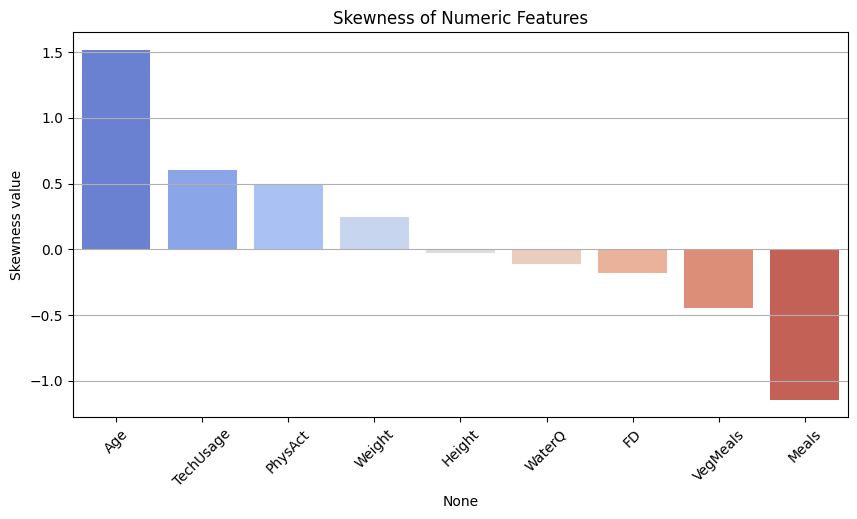

Histograms and box plots are used to visually inspect skewed distributions and outliers.


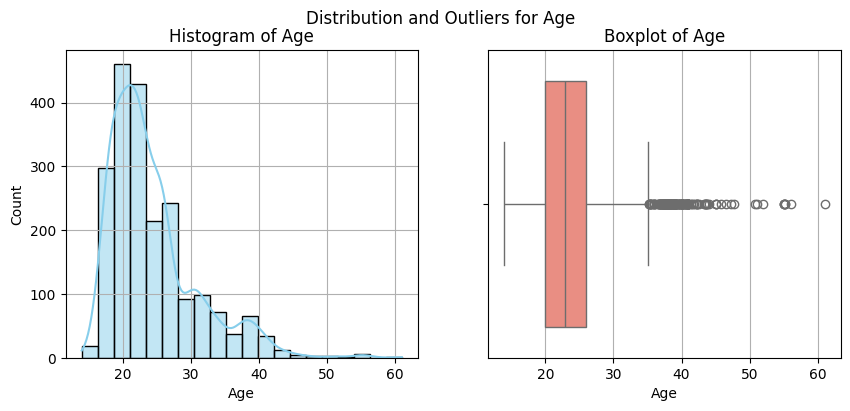

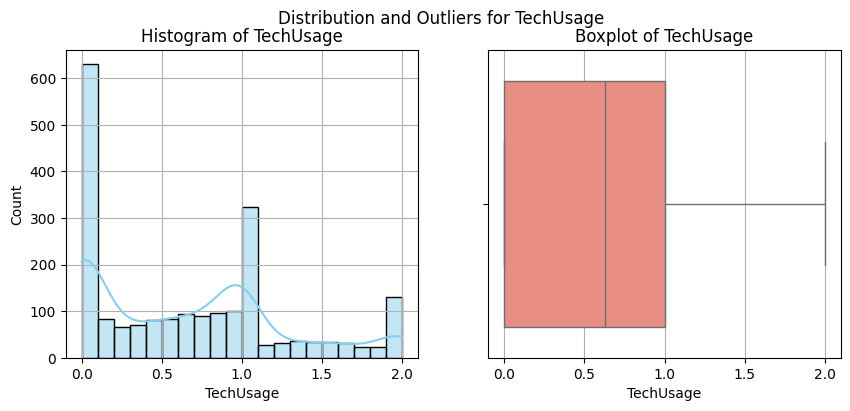

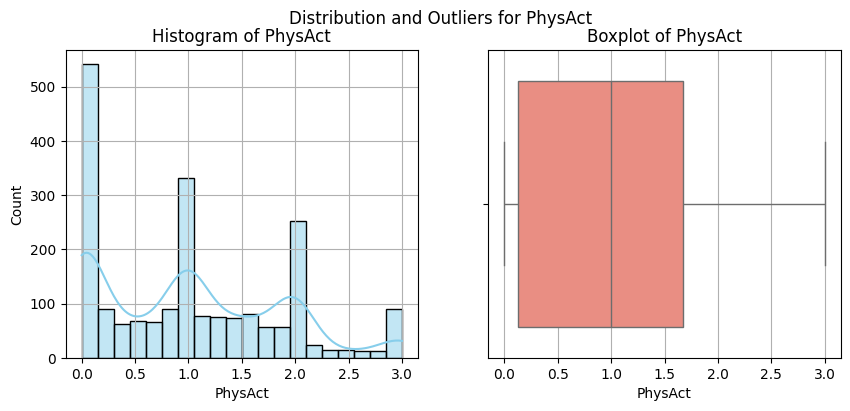

In [42]:
# Skewness analysis

if len(num_cols) > 0:
    skewness = df[num_cols].skew().sort_values(ascending=False)
    print("\nSkewness of numeric features:\n", skewness)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=skewness.index, y=skewness.values, palette="coolwarm")
    plt.xticks(rotation=45)
    plt.title("Skewness of Numeric Features")
    plt.ylabel("Skewness value")
    plt.show()
else:
    print("No numeric columns to compute skewness.")

# Discuss skewness and outliers visually
# Histograms (already shown earlier)
print("Histograms and box plots are used to visually inspect skewed distributions and outliers.")

# For visual emphasis, plot a few key ones again (e.g., top 3 most skewed)
if len(num_cols) > 0:
    top_skewed = skewness.head(3).index.tolist()
    for col in top_skewed:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        sns.histplot(df[col], bins=20, kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Histogram of {col}")
        sns.boxplot(x=df[col], ax=axes[1], color='salmon')
        axes[1].set_title(f"Boxplot of {col}")
        plt.suptitle(f"Distribution and Outliers for {col}")
        plt.show()

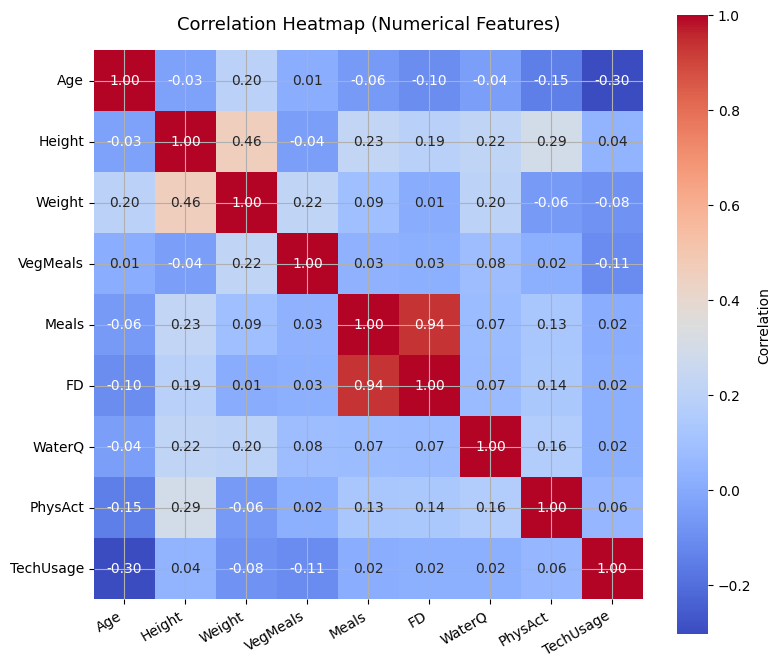

In [43]:
# Correlation heatmap
plt.figure(figsize=(8,7))
corr = df[num_cols].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={'label': 'Correlation'},
    linewidths=0.0  # remove grid lines
)

plt.title("Correlation Heatmap (Numerical Features)", fontsize=13, pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

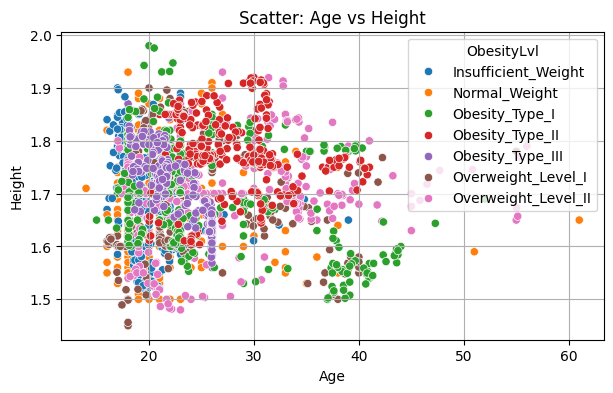

In [44]:
# Example scatter (auto-pick two numeric columns if available)

if len(num_cols) >= 2:
    xcol, ycol = num_cols[0], num_cols[1]
    plt.figure()
    sns.scatterplot(x=xcol, y=ycol, hue=target, data=df)
    plt.title(f"Scatter: {xcol} vs {ycol}")
    plt.show()


In [45]:
low_var_cols = [c for c in feature_cols if df[c].nunique() <= 1]
print("Low-variance features:", low_var_cols)
if low_var_cols:
    df = df.drop(columns=low_var_cols)
    print("Dropped low-variance features. New shape:", df.shape)

# Recompute column lists after drops
feature_cols = [c for c in df.columns if c != target]
num_cols = df[feature_cols].select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

Low-variance features: []


In [46]:
# Train/Test split

X = df[feature_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

# CV protocol

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

Train shape: (1670, 17) Test shape: (418, 17)
Train target distribution:
ObesityLvl
Obesity_Type_I         0.168263
Obesity_Type_III       0.155090
Obesity_Type_II        0.141916
Overweight_Level_II    0.138922
Normal_Weight          0.136527
Overweight_Level_I     0.131138
Insufficient_Weight    0.128144
Name: proportion, dtype: float64

Test target distribution:
ObesityLvl
Obesity_Type_I         0.167464
Obesity_Type_III       0.155502
Obesity_Type_II        0.141148
Overweight_Level_II    0.138756
Normal_Weight          0.136364
Overweight_Level_I     0.131579
Insufficient_Weight    0.129187
Name: proportion, dtype: float64


In [47]:
# Preprocessor (handles missing values, encoding, scaling)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")


---

# 2. **Model Training**

Here, you need to:

1.	select and compare at least three machine learning models (seen/discussed during the lectures) appropriate for your modelling;
2.	if there are hyperparameters in a selected algorithm, define a hyperparameter search protocol (you can define your own), and tune them.


In [48]:
# Write your proposed solution code here. Create more code cells if you find it necessary

pipe_svm = Pipeline([
    ("prep", preprocessor),
    ("clf", SVC())
])

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_dt = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_knn = Pipeline([
    ("prep", preprocessor),
    ("clf", KNeighborsClassifier())
])

# Focused grids aligned to common best practices
param_grid_svm = {
    "clf__kernel": ["rbf", "linear"],
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", "auto"]  # gamma used when kernel is rbf
}

param_grid_rf = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__class_weight": [None, "balanced"]
}

param_grid_dt = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5],
    "clf__class_weight": [None, "balanced"]
}

param_grid_knn = {
    "clf__n_neighbors": [3, 5, 7, 9, 11, 15],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["minkowski"],
    "clf__p": [1, 2]  # 1: Manhattan, 2: Euclidean
}




In [49]:
def run_search(name, pipe, grid):
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=scoring,
        refit="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=False
    )
    gs.fit(X_train, y_train)
    return name, gs

results = []
for name, pipe, grid in [
    ("SVM", pipe_svm, param_grid_svm),
    ("RandomForest", pipe_rf, param_grid_rf),
    ("DecisionTree", pipe_dt, param_grid_dt),
    ("kNN", pipe_knn, param_grid_knn),
]:
    model_name, gs = run_search(name, pipe, grid)
    results.append((model_name, gs))
def ordinal(n: int) -> str:
    return "%d%s" % (n, "tsnrhtdd"[(n//10%10!=1)*(n%10<4)*n%10::4])

rows_rank = []
for name, gs in results:
    idx = gs.best_index_
    mean_f1 = gs.cv_results_["mean_test_f1_macro"][idx]
    std_f1  = gs.cv_results_["std_test_f1_macro"][idx]
    rows_rank.append({
        "model": name,
        "best_cv_f1_macro": mean_f1,
        "std_cv_f1_macro": std_f1,
        "best_params": gs.best_params_
    })

rank_df = pd.DataFrame(rows_rank).sort_values("best_cv_f1_macro", ascending=False).reset_index(drop=True)
rank_df.insert(0, "rank", [ordinal(i+1) for i in range(len(rank_df))])
display(rank_df)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,rank,model,best_cv_f1_macro,std_cv_f1_macro,best_params
0,1st,SVM,0.960247,0.008928,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
1,2nd,DecisionTree,0.942564,0.006034,"{'clf__class_weight': None, 'clf__criterion': ..."
2,3rd,RandomForest,0.931502,0.012770,"{'clf__class_weight': 'balanced', 'clf__max_de..."
3,4th,kNN,0.860954,0.016498,"{'clf__metric': 'minkowski', 'clf__n_neighbors..."


In [50]:
rows = []
for name, gs in results:
    cvres = pd.DataFrame(gs.cv_results_)
    keep_cols = [
        "mean_test_accuracy", "std_test_accuracy",
        "mean_test_f1_macro", "std_test_f1_macro",
        "mean_test_f1_weighted", "std_test_f1_weighted",
        "params", "rank_test_f1_macro"
    ]
    cvres = cvres[keep_cols].sort_values("rank_test_f1_macro")
    cvres.insert(0, "model", name)
    rows.append(cvres)

cv_table = pd.concat(rows, ignore_index=True)

display_cols = [
    "model", "rank_test_f1_macro",
    "mean_test_f1_macro", "std_test_f1_macro",
    "mean_test_accuracy", "std_test_accuracy",
    "mean_test_f1_weighted", "std_test_f1_weighted",
    "params"
]
cv_table_display = cv_table[display_cols]
cv_table_display.head(30)


,model,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_accuracy,std_test_accuracy,mean_test_f1_weighted,std_test_f1_weighted,params
0,SVM,1,0.960247,0.008928,0.961677,0.008123,0.961487,0.008268,"{'clf__C': 10, 'clf__gamma': 'auto', 'clf__ker..."
1,SVM,1,0.960247,0.008928,0.961677,0.008123,0.961487,0.008268,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
2,SVM,3,0.955997,0.009494,0.958084,0.008468,0.957814,0.008683,"{'clf__C': 100, 'clf__gamma': 'auto', 'clf__ke..."
3,SVM,4,0.955924,0.006538,0.957485,0.006107,0.957288,0.006147,"{'clf__C': 100, 'clf__gamma': 'scale', 'clf__k..."
4,SVM,4,0.955924,0.006538,0.957485,0.006107,0.957288,0.006147,"{'clf__C': 100, 'clf__gamma': 'auto', 'clf__ke..."
5,SVM,6,0.950668,0.007828,0.952695,0.007186,0.952509,0.007210,"{'clf__C': 1, 'clf__gamma': 'auto', 'clf__kern..."
6,SVM,6,0.950668,0.007828,0.952695,0.007186,0.952509,0.007210,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker..."
7,SVM,8,0.949901,0.006744,0.952096,0.005988,0.951831,0.006166,"{'clf__C': 10, 'clf__gamma': 'auto', 'clf__ker..."
8,SVM,9,0.947661,0.014545,0.950299,0.013201,0.950242,0.013497,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke..."
9,SVM,10,0.947258,0.010997,0.950299,0.009766,0.950066,0.010052,"{'clf__C': 100, 'clf__gamma': 'scale', 'clf__k..."


In [51]:
# Save the top rows to CSV for your report appendix if needed
cv_table.to_csv("cv_results_full.csv", index=False)
print("Saved CV results to cv_results_full.csv")

Saved CV results to cv_results_full.csv


---

# 3. **Evaluate models**

Here, you need to:

1.	test the model (the best one you obtained from the above stage) on the appropriate set


Best model by CV macro-F1: SVM
Best CV score (macro-F1): 0.9602467615372076
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Test accuracy: 0.9593
Test F1 macro: 0.9582
Test F1 weighted: 0.9594

Classification report

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        54
      Normal_Weight       0.98      0.93      0.95        57
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       0.97      1.00      0.98        59
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        55
Overweight_Level_II       0.90      0.93      0.92        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418



<Figure size 800x600 with 0 Axes>

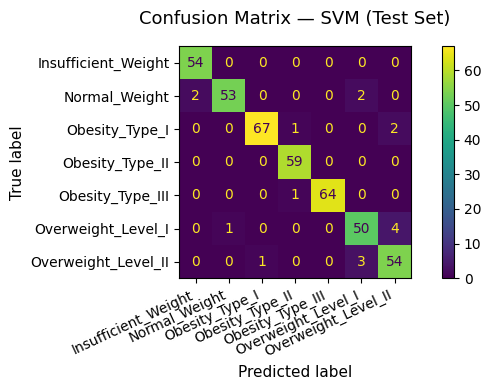

In [57]:
# Write your proposed solution code here. Create more code cells if you find it necessary
best_name, best_search = max(results, key=lambda t: t[1].best_score_)
print("Best model by CV macro-F1:", best_name)
print("Best CV score (macro-F1):", best_search.best_score_)
print("Best params:", best_search.best_params_)

best_model = best_search.best_estimator_

y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average="macro")
f1_w = f1_score(y_test, y_pred, average="weighted")

print(f"Test accuracy: {acc:.4f}")
print(f"Test F1 macro: {f1_mac:.4f}")
print(f"Test F1 weighted: {f1_w:.4f}")

print("\nClassification report\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='viridis', values_format='d', colorbar=True)
Q
plt.title("Confusion Matrix — SVM (Test Set)", fontsize=13, pad=16)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted label", fontsize=11)
plt.ylabel("True label", fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()




Top 20 Influential Features (Linear SVM):


,0
Weight,5.794548
Height,1.265426
MealsBetw_Always,0.283216
Gender_Male,0.238451
Gender_Female,0.238451
TransMeans_Automobile,0.205138
Age,0.204945
AlcConsume_Frequently,0.200649
MealsBetw_Frequently,0.199335
MealsBetw_Sometimes,0.182424


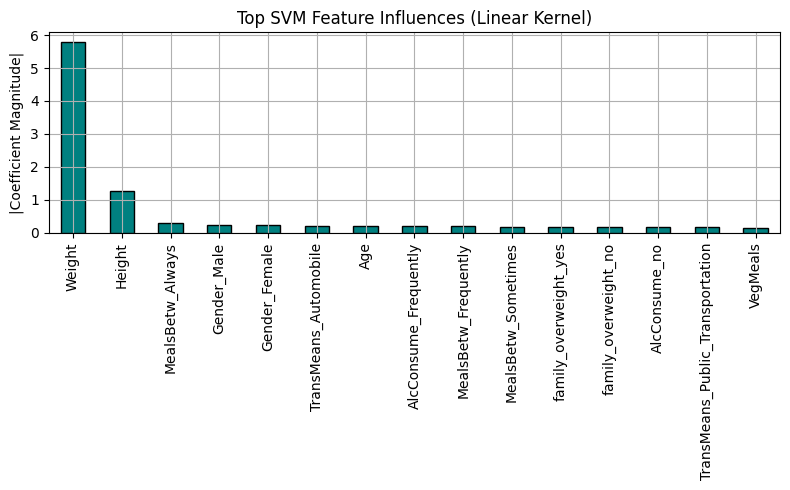

In [28]:

# Feature Importance / Interpretation
# Works for Decision Tree and Linear SVM

# Rebuild feature names from preprocessor
ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
cat_features = ohe.get_feature_names_out(cat_cols) if len(cat_cols) else np.array([])
num_features = np.array(num_cols)
all_features = np.concatenate([num_features, cat_features])

clf = best_model.named_steps["clf"]


# Decision Tree Feature Importances

if best_name == "DecisionTree":
    if hasattr(clf, "feature_importances_"):
        importances = pd.Series(
            clf.feature_importances_,
            index=all_features
        ).sort_values(ascending=False)

        print("Top 20 Important Features (Decision Tree):")
        display(importances.head(20))

        plt.figure(figsize=(8,5))
        importances.head(15).plot(kind="bar", color="orange", edgecolor="black")
        plt.title("Top Decision Tree Feature Importances", fontsize=12)
        plt.ylabel("Importance Score")
        plt.tight_layout()
        plt.show()


# Linear SVM Feature Influence
elif best_name == "SVM":
    if hasattr(clf, "coef_"):
        # Use absolute values of coefficients to measure influence strength
        coef = np.abs(clf.coef_).mean(axis=0)
        importances = pd.Series(coef, index=all_features).sort_values(ascending=False)

        print("Top 20 Influential Features (Linear SVM):")
        display(importances.head(20))

        plt.figure(figsize=(8,5))
        importances.head(15).plot(kind="bar", color="teal", edgecolor="black")
        plt.title("Top SVM Feature Influences (Linear Kernel)", fontsize=12)
        plt.ylabel("|Coefficient Magnitude|")
        plt.tight_layout()
        plt.show()


elif best_name == "RandomForest":
    importances = pd.Series(
        clf.feature_importances_,
        index=all_features
    ).sort_values(ascending=False)
    print("Top 20 Important Features (Random Forest):")
    display(importances.head(20))
    plt.figure(figsize=(8,5))
    importances.head(15).plot(kind="bar", color="forestgreen", edgecolor="black")
    plt.title("Top Random Forest Feature Importances", fontsize=12)
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

